In [1]:
!pip install numpy scipy ipympl

In [2]:
import numpy as np
from scipy import signal as sp
import random
from numpy import pi
import matplotlib.pyplot as plt
%matplotlib inline
from typing import Literal, Callable # same

# Вариант 6

### Задание

1. Ознакомиться с теоретической частью.

2. На основе лабораторной работы 1, реализовать однородный, КИХ и БИХ фильтр:

    - **однородный**: рекурсивный M=159;
  
    - **КИХ**: полосовой, Ханна, 200-800 Гц M=151;
  
    - **БИХ**: однополюсный НЧ fc=350 Гц;
  
    ---
    
    - рассчитать необходимые для реализации фильтра коэффициенты;
    
    - изменить сигнал из лабораторной работы 1 так, чтобы экспериментально подтвердить правильность работы соответствующего фильтра;
  
    - построить графики;
  
    - сохранить исходный, шумный и фильтрованый сигналы в WAV-файл.

#### Графики
  
- [x] входной функции;

- АЧХ спроектированных фильтров:

    - [x] однородный
 
    - [x] КИХ

    - [ ] БИХ

- [x] сигнала после внесения искажений;

- [x] результаты работы однородного фильтра;

- [x] результаты работы КИХ фильтра;

- [ ] результаты работы БИХ фильтра.

## HELPERS

In [3]:
def plot(y, x, f_name: str|None = None, desc: str|None = None):
    plt.figure(figsize=(9, 3))
    plt.plot(x, y)
    plt.title({
        (True, True): f"{f_name} ({desc})",
        (True, False): f"{f_name}",
        (False, True): f"{desc}",
        (False, False): None,
    }[f_name is not None, desc is not None])
    plt.grid(True)
    plt.show() 
def plot_freqspace(y_fn: Callable, f_s, f_name: str|None = None, desc: str|None = None):
    _SAMPLE_COUNT = 512
    x = np.linspace(0, _SAMPLE_COUNT / f_s, _SAMPLE_COUNT)
    f = np.linspace(0, f_s, _SAMPLE_COUNT, endpoint=False)
    f = np.fft.fftshift(f) - f_s/2
    
    plot(np.abs(np.fft.fft(y_fn(x))), f, f"FFT[{f_name}]" if f_name is not None else None, desc)
def plot_freqspace1(y, f_s, f_name: str|None = None, desc: str|None = None):
    f = np.linspace(0, f_s, len(y), endpoint=False)
    f = np.fft.fftshift(f) - f_s/2
    
    plot(np.abs(np.fft.fft(y)), f, f"FFT[{f_name}]" if f_name is not None else None, desc)

In [4]:
A_x = [1, 0.5, 0.3, 0.1]
f0_x = 262 #Hz
h_x = [1, 2, 4, 8]
phi_x = 0

In [5]:
FIR_TYPE = [0,1,0]  
FIR_F_LOW = 200   
FIR_F_HIGH = 800  
FIR_M = 151  

In [6]:
F = f0_x # base freq
F_S = 2 * 2*F*max(h_x) # optimal sampling freq
SAMPLE_COUNT = 1024

NOISE_HARMONICS = [
    (random.uniform(0.3, 0.9), random.uniform(max(h_x), 2*max(h_x))) # (amplitude, frequency multiplier)
    for i in range(3) # how many
]

In [7]:
def bandpass_noise(t, hs, f0, f_low, f_high,
                   filter_amp=0.5,     
                   boundary_amp=0.2):  
    
    existing_freqs = [h * f0 for h in hs]
    
    noise = np.zeros(len(t))
    
    has_below = any(f < f_low for f in existing_freqs)
    if not has_below:
        MUL = 0.1
        noise += filter_amp * np.sin(2*pi * (f_low * MUL) * t)  
    
    has_above = any(f > f_high for f in existing_freqs)
    if not has_above:
        MUL = 1.5
        assert(f_high * MUL < F_S / 2)
        noise += filter_amp * np.sin(2*pi * (f_high * MUL) * t)  
    
    noise += boundary_amp * np.sin(2*pi * (f_low * 0.8) * t)  
    noise += boundary_amp * np.sin(2*pi * (f_high * 1.2) * t)  
    
    return noise

# 0xF117E12 — FILTER F 1 1 7 E 12
def bandpass_expected(t, hs, As, f0, f_low, f_high):
    return sum(
        A * np.sin(2*pi * h * f0 * t)
        for h, A in zip(hs, As)
        if f_low <= h * f0 <= f_high
    )

## Сигнал

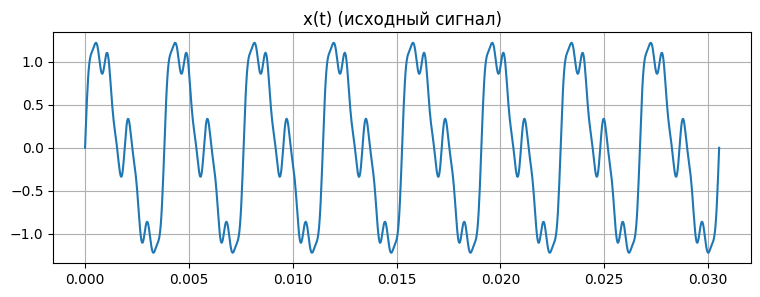

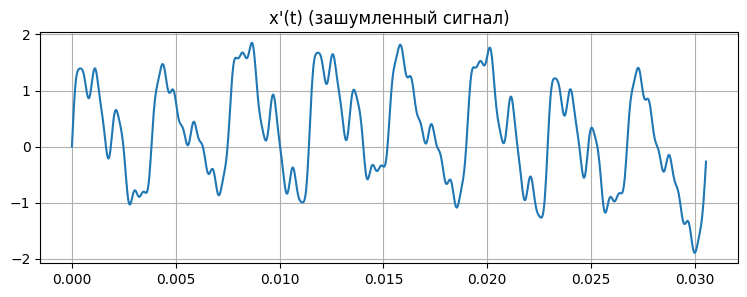

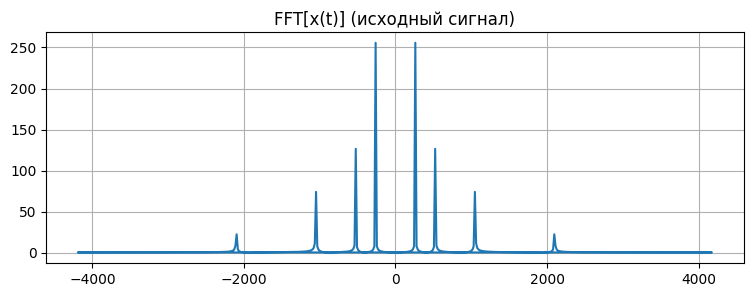

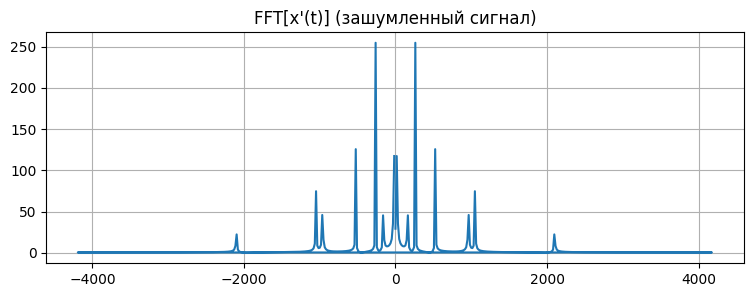

In [8]:
def s(t, A, h, f0, phi):
    assert(len(A) == len(h))
    return sum(
        A[i] * np.sin(2*pi * h[i] * f0 * t + phi)
        for i in range(0, len(A))
    )
x = lambda t: s(t, A_x, h_x, f0_x, phi_x)
#x_noisy = lambda t: x(t) + sum([a * np.sin(2*pi * f_mul*F * t) for a, f_mul in NOISE_HARMONICS])
x_noisy = lambda t: x(t) + bandpass_noise(t, h_x, f0_x, FIR_F_LOW, FIR_F_HIGH)
x_expected = lambda t: bandpass_expected(t, h_x, A_x, f0_x, FIR_F_LOW, FIR_F_HIGH)
noise_only = lambda t: bandpass_noise(t, h_x, f0_x, FIR_F_LOW, FIR_F_HIGH)

t = np.linspace(0, 8 / F, SAMPLE_COUNT)

plot(x(t), t, "x(t)", "исходный сигнал")
plot(x_noisy(t), t, "x'(t)", "зашумленный сигнал")
#plot(noise_only(t), t, "noise(t)", "шум")
#plot(x_expected(t), t, "x_exp(t)", "ожидаемый результат")
plot_freqspace(x, F_S, "x(t)", "исходный сигнал")
plot_freqspace(x_noisy, F_S, "x'(t)", "зашумленный сигнал")
#plot_freqspace(noise_only, F_S, "noise(t)", "шум")
#plot_freqspace(x_expected, F_S, "x_exp(t)", "ожидаемый результат")

## Однородный

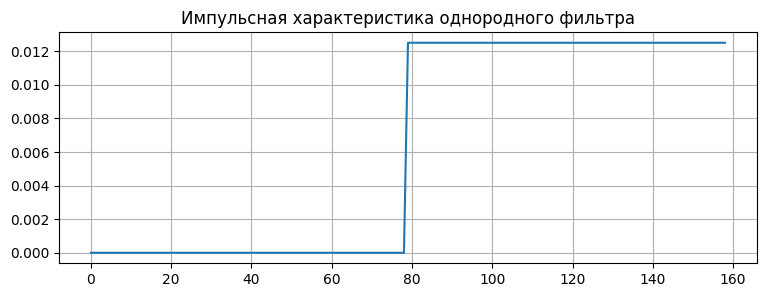

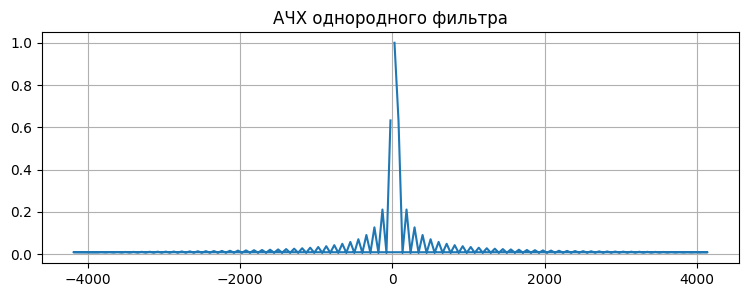

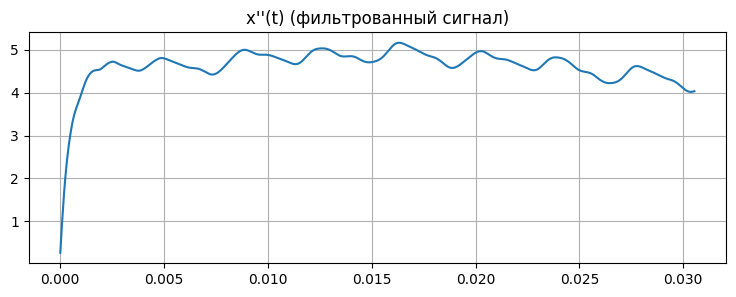

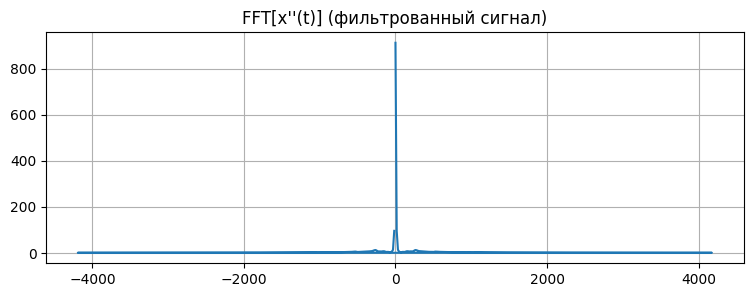

In [9]:
def homogen(x, m):
    res = np.zeros(len(x))
    for i in range(len(x)):
        k = min(i+1, m)
        res[i] = res[i-1] + (x[i] - x[i-k]) / k
    
    return res

M = 159
n = [0]*M; n[M//2] = 1
plot(homogen(n, M), np.linspace(0, M-1, M), None, "Импульсная характеристика однородного фильтра")
plot_freqspace1(homogen(n, M), F_S, None, "AЧХ однородного фильтра")

t = np.linspace(0, 8 / F, SAMPLE_COUNT)
plot(homogen(x_noisy(t), M), t, "x''(t)", "фильтрованный сигнал")
plot_freqspace(lambda t: homogen(x_noisy(t), M), F_S, "x''(t)", "фильтрованный сигнал")

## КИХ

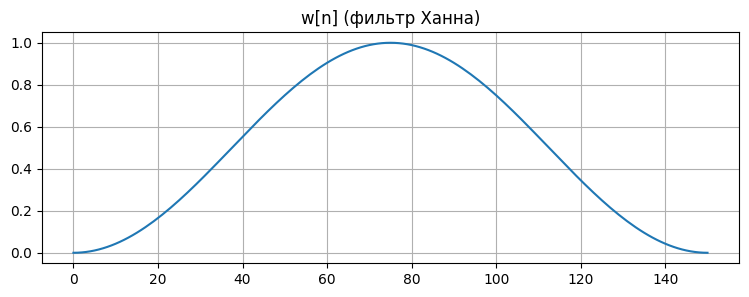

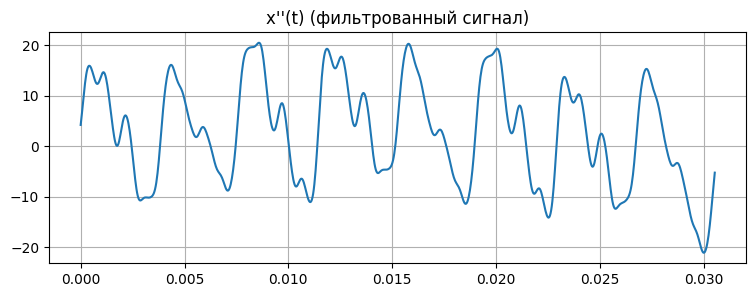

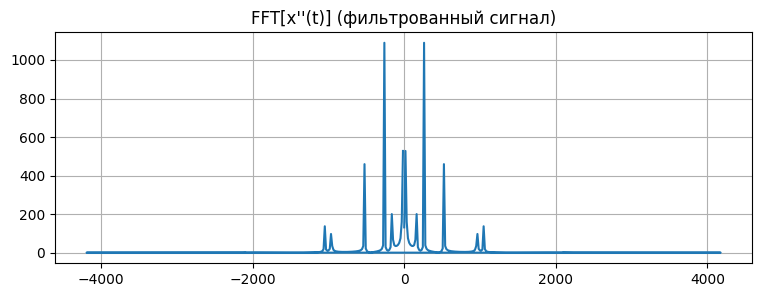

In [10]:
hanning_window = lambda n: 0.5 * (1 - np.cos(2*pi*n/(len(n)-1)))
def hanning(x, n=10): return np.convolve(x, hanning_window(np.linspace(0, n-1, n)), mode="same")

N = 151
n = np.linspace(0, N-1, N)
plot(hanning_window(n), n, "w[n]", "фильтр Ханна")

t = np.linspace(0, 8 / F, SAMPLE_COUNT)
plot(hanning(x_noisy(t), 25), t, "x''(t)", "фильтрованный сигнал")
plot_freqspace(lambda t: hanning(x_noisy(t), 10), F_S, "x''(t)", "фильтрованный сигнал")


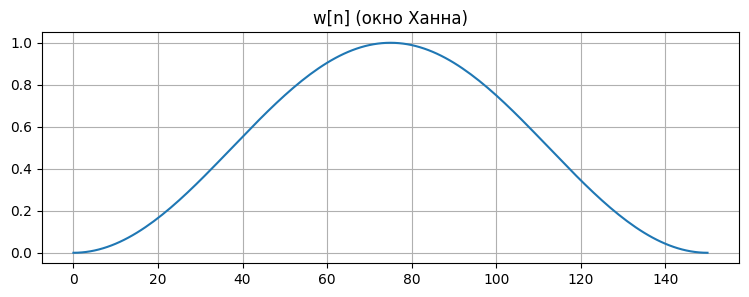

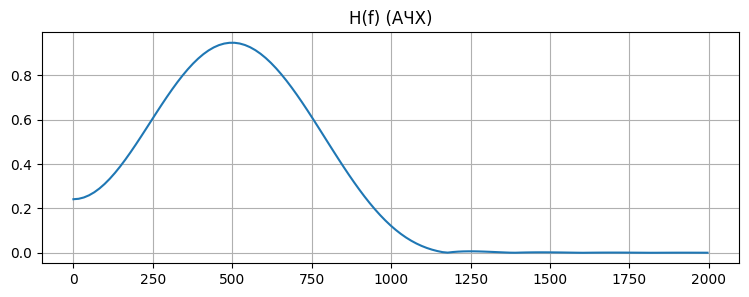

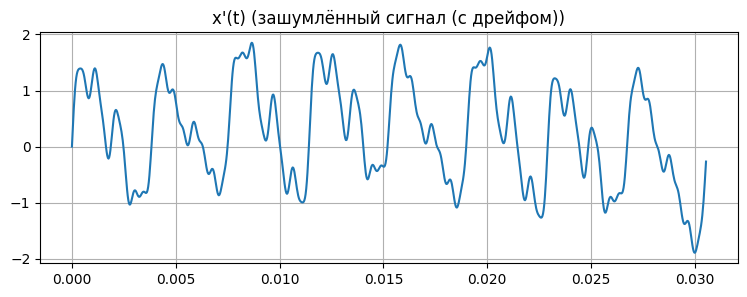

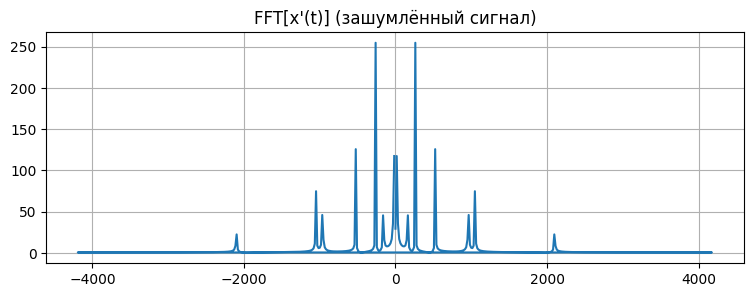

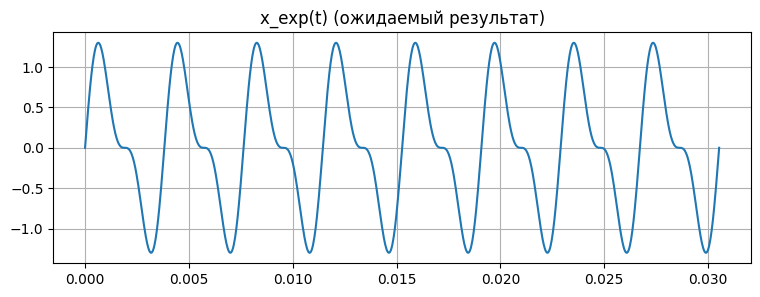

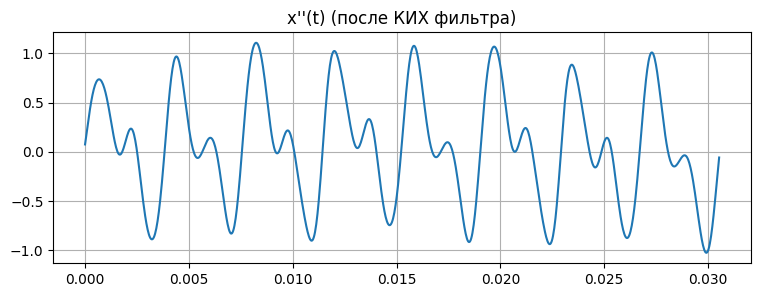

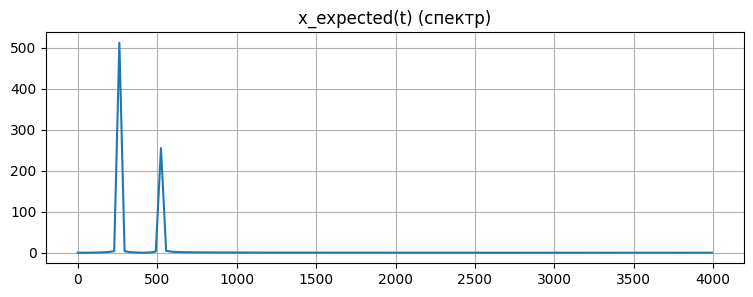

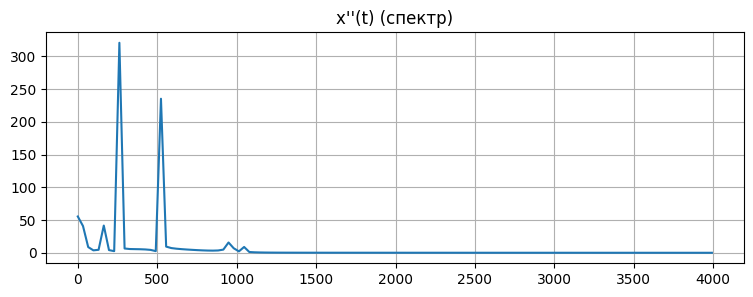

In [11]:

def make_fir_bandpass(f_low, f_high, M, fs):

    f_low_n  = f_low  / fs
    f_high_n = f_high / fs
    n = np.arange(M) - M // 2
    with np.errstate(invalid='ignore', divide='ignore'):
        h = np.where(
            n == 0,
            2 * (f_high_n - f_low_n),
            np.sin(2*np.pi*f_high_n*n) / (np.pi*n) - np.sin(2*np.pi*f_low_n*n) / (np.pi*n)
        )
    h *= hanning_window(np.arange(M))
    return h
fs_real = 1 / (t[1] - t[0])
h_fir = make_fir_bandpass(FIR_F_LOW, FIR_F_HIGH, FIR_M, fs_real)


def apply_filter(signal, h):
    result = np.convolve(signal, h, mode='same')
    # trim = len(h) // 2
    # result[:trim] = result[trim]
    # result[-trim:] = result[-trim]
    return result

t = np.linspace(0, 8 / F, SAMPLE_COUNT)


N = FIR_M
n_win = np.arange(FIR_M)
plot(hanning_window(n_win), n_win, "w[n]", "окно Ханна")

def plot_filter_ach(h, fs_real, f_name=None):
    H = np.abs(np.fft.fft(h, 2048))
    freqs = np.fft.fftfreq(2048, 1/fs_real)
    pos = (freqs >= 0) & (freqs <= 2000)  
    plot(H[pos], freqs[pos], f_name, "АЧХ")

plot_filter_ach(h_fir, fs_real, "H(f)")



plot(x_noisy(t), t, "x'(t)", "зашумлённый сигнал (с дрейфом)")
plot_freqspace(x_noisy, F_S, "x'(t)", "зашумлённый сигнал")


x_filtered = lambda t: apply_filter(x_noisy(t), h_fir)

plot(x_expected(t), t, "x_exp(t)", "ожидаемый результат")
plot(x_filtered(t), t, "x''(t)", "после КИХ фильтра")


def plot_signal_spectrum(signal, fs_real, f_name=None, f_max=4000):
    S = np.abs(np.fft.fft(signal))
    freqs = np.fft.fftfreq(len(signal), 1/fs_real)
    pos = (freqs >= 0) & (freqs <= f_max)
    plot(S[pos], freqs[pos], f_name, "спектр")

plot_signal_spectrum(x_expected(t), fs_real, "x_expected(t)")
plot_signal_spectrum(x_filtered(t), fs_real, "x''(t)")

33503.25
8384


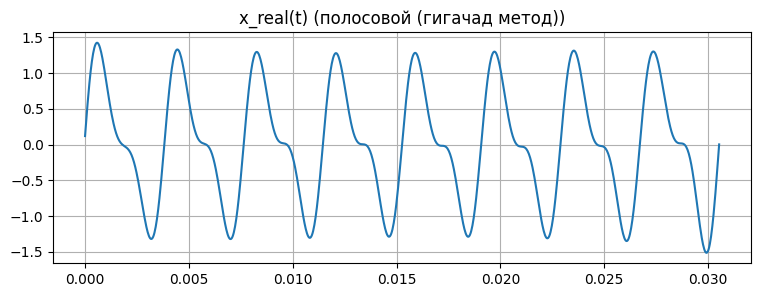

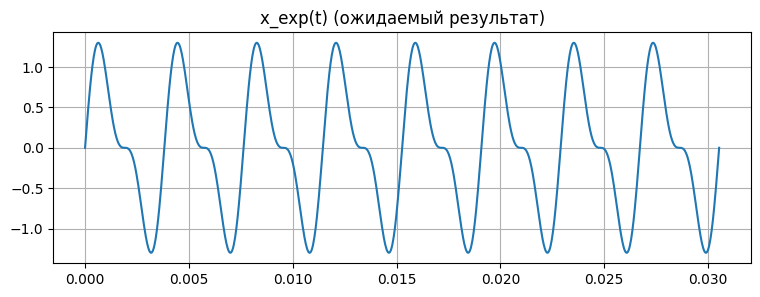

In [12]:
def bandpass_gigachad(signal, f_low, f_high, fs):
    # 0x12EA1 0xF117E12
    N = len(signal)
    fs_real = 1 / (t[1] - t[0])
    print(fs_real)
    print(F_S)
    freqs = np.fft.fftfreq(N, 1/fs_real)
    S = np.fft.fft(signal)

    mask = (np.abs(freqs) >= f_low) & (np.abs(freqs) <= f_high)
    S_filtered = S * mask
    return np.real(np.fft.ifft(S_filtered))

filtered_chad = bandpass_gigachad(x_noisy(t), FIR_F_LOW, FIR_F_HIGH, F_S)
plot(filtered_chad, t, "x_real(t)", "полосовой (гигачад метод)")
plot(x_expected(t), t, "x_exp(t)", "ожидаемый результат")